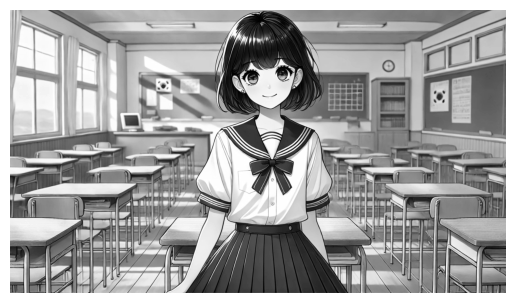

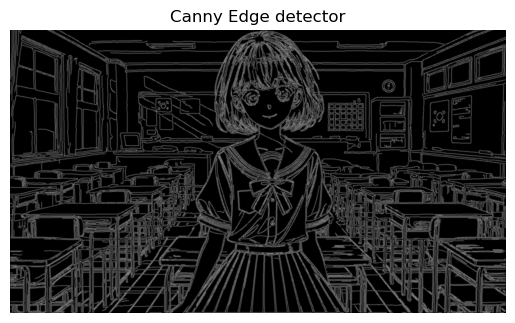

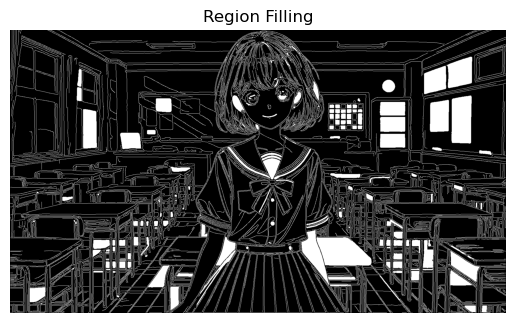

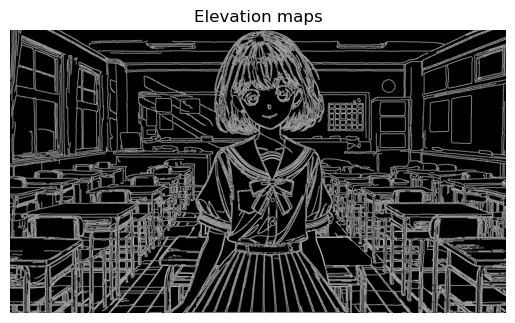

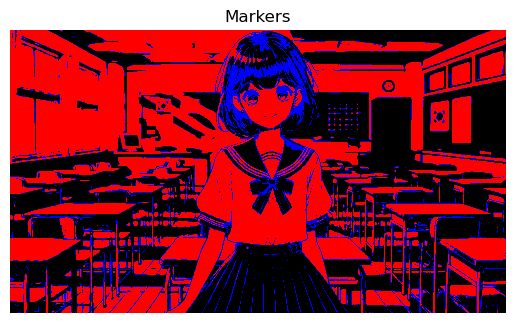

In [55]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import canny
from skimage import morphology, filters
import scipy.ndimage as nd
from matplotlib.colors import ListedColormap

image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\my story\chr\10880e35-8699-4aea-aab2-5bf015ca6753.jpg", 0)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

edges = canny(image)
plt.imshow(edges, interpolation='gaussian', cmap='gray')
plt.title('Canny Edge detector')
plt.axis('off')
plt.show()

fill_im = nd.binary_fill_holes(edges)
plt.imshow(fill_im, cmap='gray')
plt.title('Region Filling')
plt.axis('off')
plt.show()

elevation_map = filters.sobel(fill_im)
plt.imshow(elevation_map, cmap='gray')
plt.title('Elevation maps')
plt.axis('off')
plt.show()

markers = np.zeros_like(image)
markers[image < 30] = 1  
markers[image > 150] = 2  

cmap = ListedColormap(["black", "blue", "red"])  

plt.imshow(markers, cmap=cmap)
plt.title('Markers')
plt.axis('off')
plt.show()

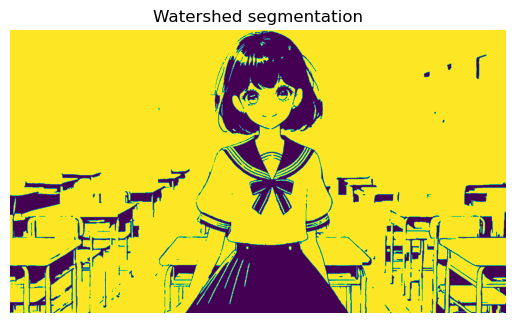

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import canny
from skimage import data,morphology, filters, segmentation 
from skimage.color import rgb2gray
import scipy.ndimage as nd

segmentation = segmentation.watershed(elevation_map, markers)

plt.imshow(segmentation)
plt.title('Watershed segmentation')
plt.axis('off')
plt.show()

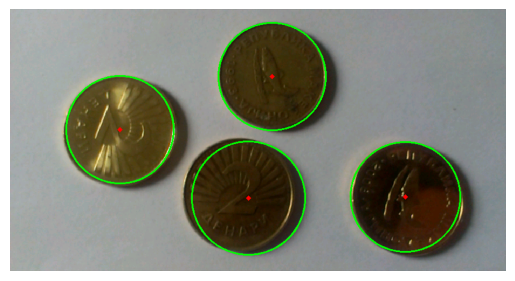

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
coins = cv2.imread(r"C:\Users\shema\Downloads\coin.png")
gray = cv2.medianBlur(cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY), 5)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 40, param1=50, param2=30, minRadius=75, maxRadius=115)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(coins, (i[0], i[1]), i[2], (0, 255, 0), 2)  
        cv2.circle(coins, (i[0], i[1]), 2, (0, 0, 255), 3) 
plt.imshow(cv2.cvtColor(coins, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

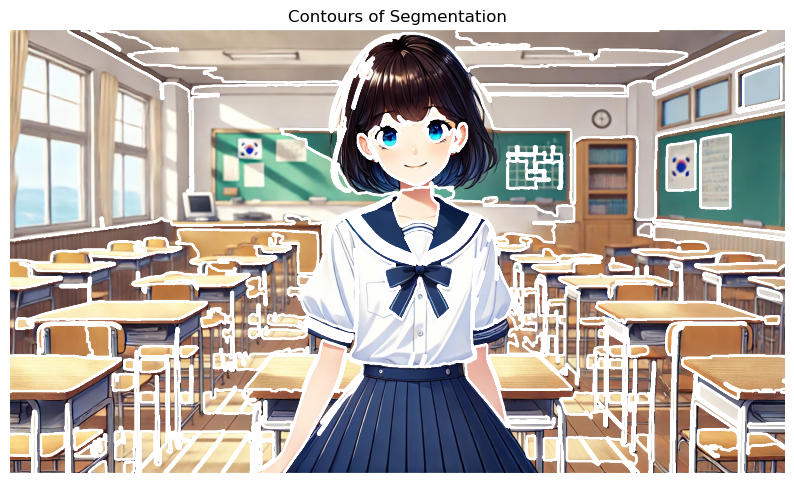

In [112]:
contours = measure.find_contours(edges, level=0.5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image, cmap='gray')  

for contour in contours:
    ax.plot(contour[:, 1], contour[:, 0], linewidth=1.5, color='white')

ax.set_title("Contours of Segmentation")
ax.axis("off")
plt.show()

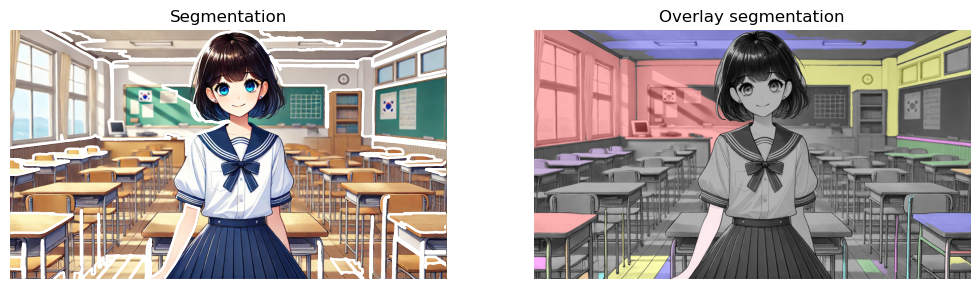

In [106]:
from skimage.color import rgb2gray, label2rgb

segmentation = nd.binary_fill_holes(segmentation - 1)
label_rock, _ = nd.label(segmentation)

image_label_overlay = label2rgb(label_rock, image=image_rgb)

fig, (axes) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].imshow(image_rgb)
axes[0].contour(segmentation, [0.8], linewidths=1.8, colors='w')
axes[0].set_title('Segmentation')
axes[0].axis('off')
axes[1].imshow(image_label_overlay)
axes[1].set_title('Overlay segmentation')
axes[1].axis('off')
plt.tight_layout()

margins = {
    "left": 0.1,
    "right": 0.9,
    "bottom": 0.1,
    "top": 0.9,
    "wspace": 0.2,
    "hspace": 0.2
}

fig.subplots_adjust(**margins)
plt.axis('off')
plt.show()

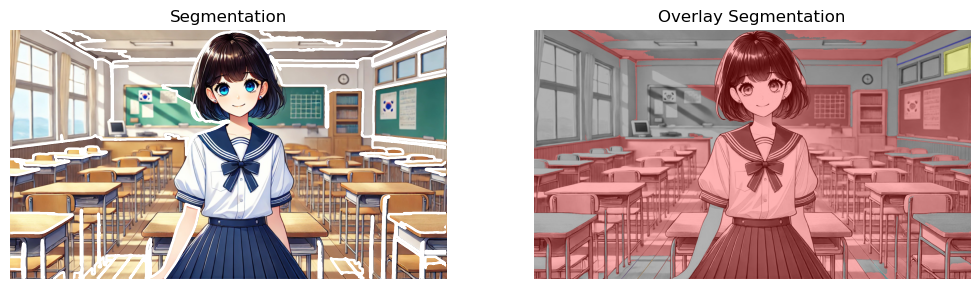

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd
from skimage.color import label2rgb

segmentation = nd.binary_fill_holes(segmentation - 1)
label_rock, _ = nd.label(segmentation)

image_label_overlay = label2rgb(label_rock, image=image_rgb, bg_label=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].imshow(image_rgb)
axes[0].contour(segmentation, levels=[0.8], linewidths=1.8, colors='w')
axes[0].set_title('Segmentation')
axes[0].axis('off')

axes[1].imshow(image_label_overlay)
axes[1].set_title('Overlay Segmentation')
axes[1].axis('off')

fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.2, hspace=0.2)

plt.show()


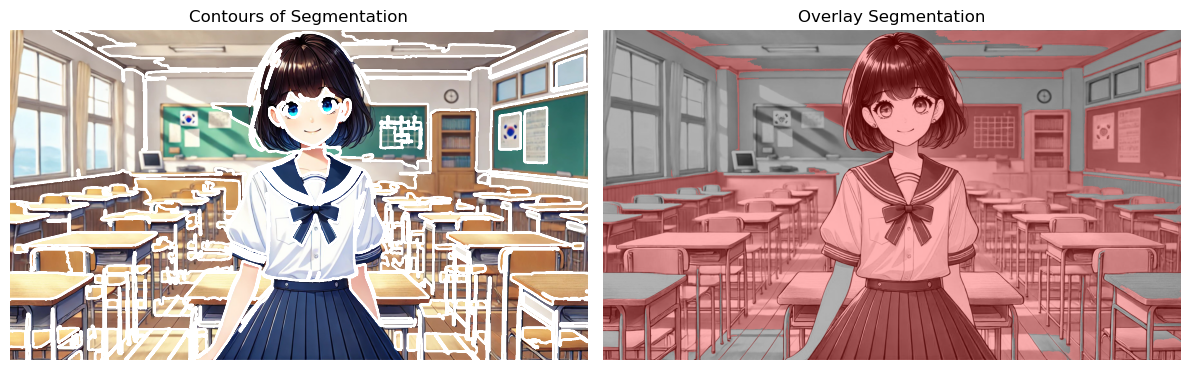

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure, color

# Find contours
contours = measure.find_contours(edges, level=0.5)

# Create a labeled segmentation overlay
label_overlay = color.label2rgb(segmentation, image=image, bg_label=0)

# Plot original image with contours
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].imshow(image, cmap='gray')
for contour in contours:
    axes[0].plot(contour[:, 1], contour[:, 0], linewidth=1.5, color='white')
axes[0].set_title("Contours of Segmentation")
axes[0].axis("off")

# Plot overlay segmentation
axes[1].imshow(label_overlay)
axes[1].set_title("Overlay Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()


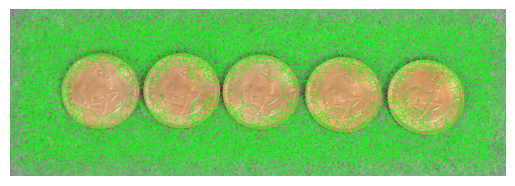

In [119]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
coins = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\c.jpg")
gray = cv2.medianBlur(cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY), 5)
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, 40, param1=50, param2=30, minRadius=75, maxRadius=115)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(coins, (i[0], i[1]), i[2], (0, 255, 0), 2)  
        cv2.circle(coins, (i[0], i[1]), 2, (0, 0, 255), 3) 
plt.imshow(cv2.cvtColor(coins, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

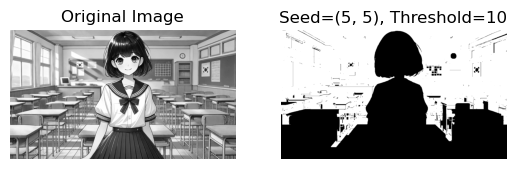

In [123]:
import numpy as np
import cv2
import pandas as pd
from scipy.ndimage import label
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region(image, seed, threshold):
    rows, cols = image.shape
    segmented_image = np.zeros_like(image)


    segmented_image[seed] = 255

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    to_process = [seed]

    while to_process:
        current_pixel = to_process.pop()
        x, y = current_pixel

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < rows and 0 <= ny < cols:
                if segmented_image[nx, ny] == 0:
                    if abs(int(image[x, y]) - int(image[nx, ny])) <= threshold:
                        segmented_image[nx, ny] = 255
                        to_process.append((nx, ny))

    return segmented_image

image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\my story\chr\10880e35-8699-4aea-aab2-5bf015ca6753.jpg")

image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

seed = (5, 5)
threshold = 10

segmented_image = region(image_gray, seed, threshold)

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title(f"Seed={seed}, Threshold={threshold}")
plt.axis("off")

plt.show()

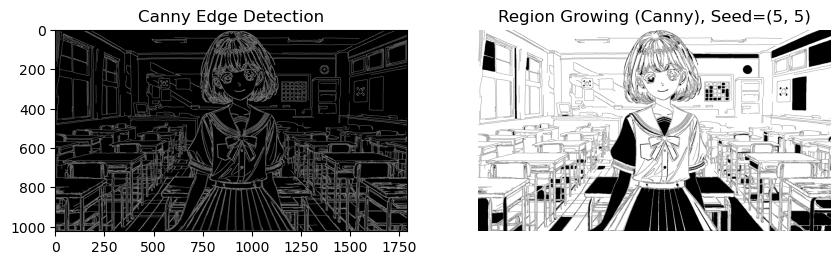

In [125]:
def canny_edge_detection(image, low_threshold, high_threshold):
    edges = cv2.Canny(image, low_threshold, high_threshold)
    return edges

def region(image, seed, threshold):
    rows, cols = image.shape
    segmented_image = np.zeros_like(image)


    segmented_image[seed] = 255

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    to_process = [seed]

    while to_process:
        current_pixel = to_process.pop()
        x, y = current_pixel

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < rows and 0 <= ny < cols:
                if segmented_image[nx, ny] == 0:
                    if abs(int(image[x, y]) - int(image[nx, ny])) <= threshold:
                        segmented_image[nx, ny] = 255
                        to_process.append((nx, ny))

    return segmented_image

image = cv2.imread(r"/content/cricket.jpg")

low_threshold = 50
high_threshold = 150
edge_image_canny = canny_edge_detection(image_gray, low_threshold, high_threshold)

# Apply region growing
segmented_image_canny = region(edge_image_canny, seed, threshold)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(edge_image_canny, cmap='gray')
plt.title('Canny Edge Detection')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image_canny, cmap='gray')
plt.title(f"Region Growing (Canny), Seed={seed}")
plt.axis("off")

plt.show()


In [127]:

def prewitt_edge_detection(image):

    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    gradient_x = cv2.filter2D(image, -1, prewitt_x)
    gradient_y = cv2.filter2D(image, -1, prewitt_y)

    magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    magnitude = np.uint8(np.clip(magnitude, 0, 255))

    return magnitude

def region(image, seed, threshold):
    rows, cols = image.shape
    segmented_image = np.zeros_like(image)

    segmented_image[seed] = 255

    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    to_process = [seed]

    while to_process:
        current_pixel = to_process.pop()
        x, y = current_pixel

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < rows and 0 <= ny < cols:

                if segmented_image[nx, ny] == 0:

                    if abs(int(image[x, y]) - int(image[nx, ny])) <= threshold:
                        segmented_image[nx, ny] = 255
                        to_process.append((nx, ny))

    return segmented_image


image = cv2.imread(r"/content/cricket.jpg")
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edge_image_prewitt = prewitt_edge_detection(image_gray)

seed = (100, 100)
threshold = 25
segmented_image_prewitt = region(edge_image_prewitt, seed, threshold)

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(edge_image_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image_prewitt, cmap='gray')
plt.title(f"Region Growing (Prewitt), Seed={seed}")
plt.axis("off")

plt.show()

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
